## Numbers Dataset

We have a dataset of handwritten digits from 0 to 9

We need some library to read the images, I've chosen the pillow library which comes with Anaconda, if you need to 

pip install Pillow

should install it for you

In [31]:
import numpy as np
import glob
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
from sklearn.model_selection import train_test_split

In [32]:
##Printing Examples
def printexamples(X, y, examples_per_class = 10, number_of_classes = 10, mult = 1.0):
    pos = 0
    data = pd.DataFrame(y, columns=["yvalue"])
    for cls in range(number_of_classes):
        this_class = data[data["yvalue"] == cls]
        idxs = this_class.sample(examples_per_class).index
        for i, idx in enumerate(idxs):
            plt.subplot(examples_per_class, number_of_classes, i * number_of_classes + cls + 1)
            plt.imshow((X[idx]*mult).reshape(20,20).astype('uint8'), cmap='gray')
            plt.axis('off')
            if i == 0:
                plt.title(str(cls))
    plt.show()

In [33]:
# Load the image files
filelist = glob.glob('data/*/*.png')


X = np.array([Image.open(f)for f in filelist])


# Create target from filenames
y = np.array([int(fname.split('/')[-2]) for fname in filelist])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y sample: {y[:20]}")

X shape: (5000, 20, 20)
y shape: (5000,)
y sample: [9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9]


In [34]:
# Check pixel value ranges
print(f"Min pixel value: {X.min()}")
print(f"Max pixel value: {X.max()}")

Min pixel value: 0
Max pixel value: 255


In [35]:
X = X.reshape(5000,400)

In [36]:
# Scale data [0, 1]
X = X / 255.0

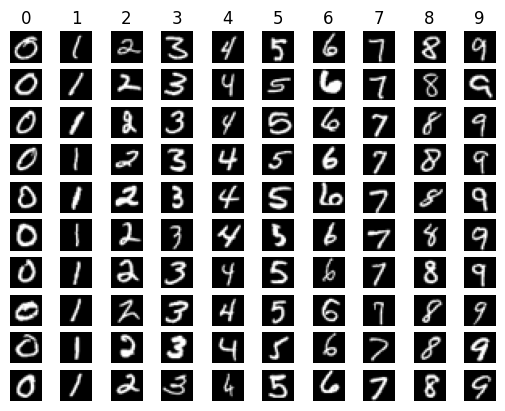

In [37]:
# Print examples
printexamples(X, y, mult=255.0)

In [38]:
# Split into train/validation/test (60/20/20)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (3000, 400), Val: (1000, 400), Test: (1000, 400)


In [39]:
# Section 2: Linear Support Vector Machine
from sklearn.svm import SVC

# Train linear SVM
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

print("Linear SVM trained successfully")

Linear SVM trained successfully


In [40]:
# Calculate training and validation accuracy
train_acc = svm_linear.score(X_train, y_train)
val_acc = svm_linear.score(X_val, y_val)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Difference: {train_acc - val_acc:.4f}")

Training Accuracy: 0.9953
Validation Accuracy: 0.9300
Difference: 0.0653


Moderate overfitting is present

In [41]:
from sklearn.metrics import confusion_matrix, classification_report

# Confusion matrix and classification report on validation set
y_val_pred = svm_linear.predict(X_val)

# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred)
print("Confusion Matrix:")
print(cm)
print()

# Classification report
print("Classification Report:")
print(classification_report(y_val, y_val_pred))

Confusion Matrix:
[[95  0  2  0  1  1  0  1  0  0]
 [ 0 99  1  0  0  0  0  0  0  0]
 [ 1  7 84  4  1  0  0  1  1  1]
 [ 0  0  0 94  0  3  0  0  2  1]
 [ 0  2  0  0 95  0  1  1  0  1]
 [ 1  0  1  2  0 91  0  0  4  1]
 [ 1  0  1  0  0  1 97  0  0  0]
 [ 1  0  1  0  1  0  0 94  0  3]
 [ 1  2  2  2  0  2  0  0 89  2]
 [ 0  0  1  1  2  0  0  4  0 92]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       100
           1       0.90      0.99      0.94       100
           2       0.90      0.84      0.87       100
           3       0.91      0.94      0.93       100
           4       0.95      0.95      0.95       100
           5       0.93      0.91      0.92       100
           6       0.99      0.97      0.98       100
           7       0.93      0.94      0.94       100
           8       0.93      0.89      0.91       100
           9       0.91      0.92      0.92       100

    accuracy                   

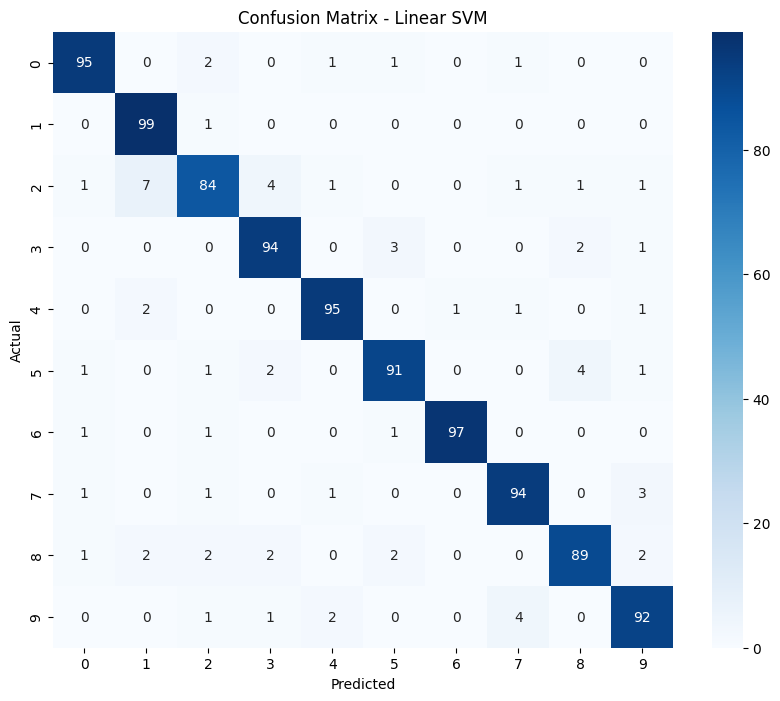

In [42]:
# Visualize confusion matrix
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Linear SVM')
plt.show()

Most confused is 2 being predicted as 1: 7 times

In [43]:
from sklearn.model_selection import GridSearchCV

# Tune C parameter using 5-fold cross-validation
# Test a range of C values (regularization parameter)
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(
    SVC(kernel='linear'),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1
)

grid_search.fit(X_train, y_train)

# Print results
print(f"Best C: {grid_search.best_params_['C']}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
print("\nAll cross-validation scores:")
for mean_score, params in zip(grid_search.cv_results_['mean_test_score'], 
                               grid_search.cv_results_['params']):
    print(f"C={params['C']:>6}: {mean_score:.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best C: 0.1
Best cross-validation score: 0.9200

All cross-validation scores:
C=  0.01: 0.9047
C=   0.1: 0.9200
C=     1: 0.9040
C=    10: 0.9013
C=   100: 0.9013


In [44]:
# Retrain using the best C on the training set
best_svm = SVC(kernel='linear', C=0.1)
best_svm.fit(X_train, y_train)

# Report validation accuracy
val_acc_tuned = best_svm.score(X_val, y_val)
train_acc_tuned = best_svm.score(X_train, y_train)

print(f"Best C value: 0.1")
print(f"Training Accuracy (with C=0.1): {train_acc_tuned:.4f}")
print(f"Validation Accuracy (with C=0.1): {val_acc_tuned:.4f}")
print(f"Difference: {train_acc_tuned - val_acc_tuned:.4f}")

Best C value: 0.1
Training Accuracy (with C=0.1): 0.9617
Validation Accuracy (with C=0.1): 0.9370
Difference: 0.0247


In [45]:
# Section 3: Random Forest
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train, y_train)

# Report training and validation accuracy
train_acc_rf = rf_default.score(X_train, y_train)
val_acc_rf = rf_default.score(X_val, y_val)

print(f"Training Accuracy: {train_acc_rf:.4f}")
print(f"Validation Accuracy: {val_acc_rf:.4f}")
print(f"Difference: {train_acc_rf - val_acc_rf:.4f}")

Training Accuracy: 1.0000
Validation Accuracy: 0.9430
Difference: 0.0570


Model is overfit, training accuracy is at 100% so its memorised the training set perfectly but the lower validation score means its less performant with unseen data

Confusion Matrix - Random Forest:
[[96  0  1  0  1  0  1  0  1  0]
 [ 0 99  1  0  0  0  0  0  0  0]
 [ 3  2 90  1  0  0  0  3  1  0]
 [ 0  0  1 93  0  3  0  0  2  1]
 [ 0  1  0  0 93  0  1  0  0  5]
 [ 1  1  1  1  0 94  0  0  1  1]
 [ 2  0  0  0  0  1 97  0  0  0]
 [ 0  3  2  0  0  0  0 93  0  2]
 [ 0  0  1  3  0  0  0  0 93  3]
 [ 0  0  0  1  1  0  0  2  1 95]]

Classification Report - Random Forest:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       100
           1       0.93      0.99      0.96       100
           2       0.93      0.90      0.91       100
           3       0.94      0.93      0.93       100
           4       0.98      0.93      0.95       100
           5       0.96      0.94      0.95       100
           6       0.98      0.97      0.97       100
           7       0.95      0.93      0.94       100
           8       0.94      0.93      0.93       100
           9       0.89      0.95      0.92       100


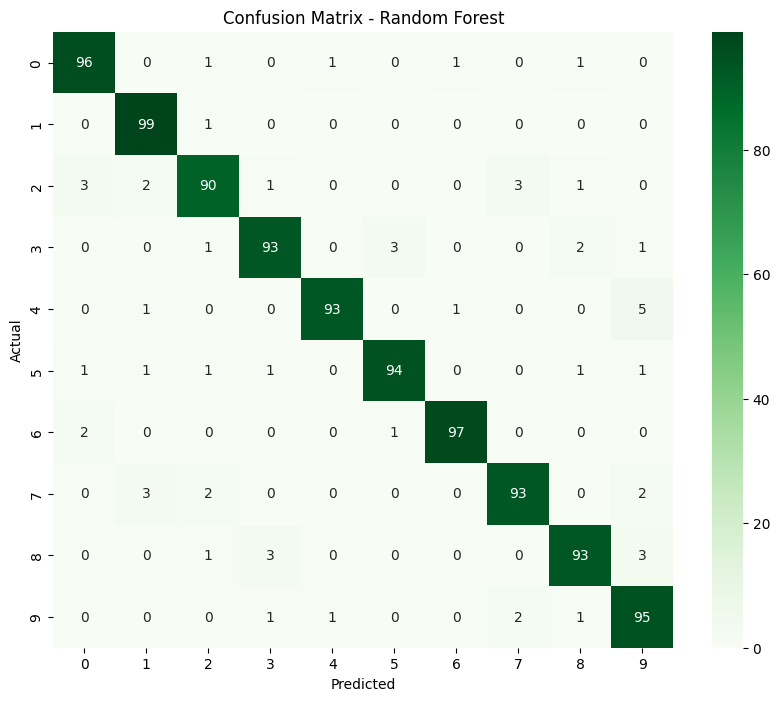

In [46]:
# Confusion matrix and classification report for Random Forest
y_val_pred_rf = rf_default.predict(X_val)

# Confusion matrix
cm_rf = confusion_matrix(y_val, y_val_pred_rf)
print("Confusion Matrix - Random Forest:")
print(cm_rf)
print()

# Classification report
print("Classification Report - Random Forest:")
print(classification_report(y_val, y_val_pred_rf))

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [47]:
# Tune n_estimators and max_depth using 5-fold cross-validation
param_grid_rf = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [10, 20, 30, None]
}

grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1  # Use all CPU cores to speed up
)

grid_search_rf.fit(X_train, y_train)

# Print results
print(f"Best parameters: {grid_search_rf.best_params_}")
print(f"Best cross-validation score: {grid_search_rf.best_score_:.4f}")
print("\nTop 5 combinations:")
results_df = pd.DataFrame(grid_search_rf.cv_results_)
top_5 = results_df.nlargest(5, 'mean_test_score')[['params', 'mean_test_score']]
for idx, row in top_5.iterrows():
    print(f"{row['params']}: {row['mean_test_score']:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters: {'max_depth': 30, 'n_estimators': 300}
Best cross-validation score: 0.9307

Top 5 combinations:
{'max_depth': 30, 'n_estimators': 300}: 0.9307
{'max_depth': None, 'n_estimators': 300}: 0.9307
{'max_depth': 20, 'n_estimators': 300}: 0.9303
{'max_depth': 20, 'n_estimators': 200}: 0.9280
{'max_depth': 20, 'n_estimators': 100}: 0.9277


In [49]:
# Retrain using best parameters on the training set
best_rf = RandomForestClassifier(max_depth=30, n_estimators=300, random_state=42)
best_rf.fit(X_train, y_train)

# Report validation accuracy
val_acc_rf_tuned = best_rf.score(X_val, y_val)
train_acc_rf_tuned = best_rf.score(X_train, y_train)

print(f"Best parameters: max_depth=30, n_estimators=300")
print(f"Training Accuracy (tuned): {train_acc_rf_tuned:.4f}")
print(f"Validation Accuracy (tuned): {val_acc_rf_tuned:.4f}")
print(f"Difference: {train_acc_rf_tuned - val_acc_rf_tuned:.4f}")
print(f"\nValidation accuracy saved for comparison: {val_acc_rf_tuned:.4f}")

Best parameters: max_depth=30, n_estimators=300
Training Accuracy (tuned): 1.0000
Validation Accuracy (tuned): 0.9430
Difference: 0.0570

Validation accuracy saved for comparison: 0.9430
